# Day 2 - Cleaning Data : Case Study Titanic Dataset

Dalam Dunia nyata, Jarang terdapat Data yang rapih dan bisa digunakan langsung.

Dalam banyak kasus didunianya, Banyak data yang mengandung Missing Value, data Duplicate dan Tipe Data yang tidak sesuai dengan ketentuan.

Pada Latihan kali ini saya menggunakan dataset Titanic dari Kaggle, Untuk menyelesaikan Case Studi **Cleaning Data**


> 🎯 **Tujuan Pembelajaran**
> - Mendeteksi *missing value* (nilai yang hilang) dan menghitungnya.
> - Memilih strategi imputasi yang tepat (median, modus, atau drop kolom).
> - Mengecek & menghapus data duplikat.
> - Mengonversi tipe data agar lebih bermakna.
> - Memvisualisasikan pola kelangkaan data dan tingkat keselamatan penumpang.

# Tentang Dataset


Kita memakai **Titanic Dataset**, berisi data 891 penumpang kapal RMS Titanic yang
tenggelam tahun 1912. Tujuan klasiknya: memprediksi siapa yang selamat.

- **Sumber:** [Kaggle — yasserh/titanic-dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)
- **Jumlah data:** 891 baris × 12 kolom

| Kolom | Arti |
|-------|------|
| `Survived` | 0 = meninggal, 1 = selamat |
| `Pclass` | Kelas tiket (1 = atas, 3 = ekonomi) |
| `Sex` | Jenis kelamin |
| `Age` | Umur (banyak yang kosong) |
| `SibSp` | Jumlah saudara/pasangan di kapal |
| `Parch` | Jumlah orang tua/anak di kapal |
| `Fare` | Harga tiket |
| `Cabin` | Nomor kabin (sangat banyak yang kosong) |
| `Embarked` | Pelabuhan naik (C, Q, S) |


# Import Dataset & Library

In [30]:
# Instal Kaggle
!pip install -q kaggle

# Pastikan file kaggle.json sudah di-upload ke Colab
# Jalankan perintah ini untuk mendownload dan unzip otomatis
!kaggle datasets download -d yasserh/titanic-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
100% 22.0k/22.0k [00:00<00:00, 33.8MB/s]



Penggunaan Library


- **pandas** → membaca & mengolah data berbentuk tabel.
- **numpy** → operasi angka/array.
- **matplotlib** & **seaborn** → membuat grafik.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Explorasi Awal Data menggunakan Statistic

In [32]:
# Pengaturan tampilan grafik
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Interpretasi :    
Setiap 1 Baris merepresentasikan 1 data penumpang:  mulai dari
- ID,
- Bertahan/Tidak,
- Jenis Kelas,
- Nama,
- Jenis Kelamin,
- Umur,
- Saudara dalam perjalanan di kapal,
- Orang tua dalam perjalanan dikapal,
- harga tiket,
- Nomor Kabin,
- Tipe Pelabuhan

In [33]:
#Ukuran Data : ( Jumlah Baris dan Kolom )

print(f'baris : {df.shape[0]}')
print(f'kolom : {df.shape[1]}')

baris : 891
kolom : 12


Ada **891 baris** (penumpang) dan **12 kolom**.

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


dari .info(). diketahui :    


*   terdapat Missing Value dalam dataset Titanic, pada kolom Age, Cabin dan Embarked

*   Terdapat beberapa tipe data ( int, Object dan Float )
*   Data ini Belum bersih



In [35]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Age,177
Cabin,687
Embarked,2


**Interpretasi:** Ada tiga kolom bermasalah:
- `Age` → 177 hilang (~20%): masih layak diisi (imputasi).
- `Cabin` → 687 hilang (~77%): terlalu banyak, lebih baik **dibuang**.
- `Embarked` → 2 hilang: sangat sedikit, bisa diisi dengan nilai yang paling sering muncul.

In [36]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


dapat di interpretasikan sebagai berikut :     
- Total Jumlah Penumpang 891, dan sekitar 38% Penumpang selamat,
- Rata rata penumpang adalah kelas menengah keatas
- Rata rata umur penumpang di sekitar 29-30 tahun
- Rata rata penumpang tidak bersama pasangan mereka/keluarganya atau sendirian
- Harga tiket Rata rata adalah 32.000

# Data Cleaning

## a) Mengisi Nilai Hilang (age) dengan median

Untuk mengisi nilai yang hilang ini menggunakan teknik imputasi median, karna median lebih tahan dengan nilai yang ekstrem

In [38]:
age_md_classs = df.groupby("Pclass")["Age"].transform("median")
print(f"Median umur:{age_md_classs}")

df['Age'] = df['Age'].fillna(age_md_classs)
print("sisa umur kosong:", df['Age'].isnull().sum())

Median umur:0      24.0
1      37.0
2      24.0
3      37.0
4      24.0
       ... 
886    29.0
887    37.0
888    24.0
889    37.0
890    24.0
Name: Age, Length: 891, dtype: float64
sisa umur kosong: 0


## b) Mengisi Nilai Hilang (Embarked) dengan modus

Karna hanya 2 kolom nilai yang hilang, kita menggunakan modus, nilai yang sering muncul untuk mengisi kolom yang hilang ini

In [39]:
emb_mod = df['Embarked'].mode()[0]
print(f"Modus Pelabuhan: {emb_mod}")

df['Embarked'] = df['Embarked'].fillna(emb_mod)
print("sisa embarked kosong:", df['Embarked'].isnull().sum())

Modus Pelabuhan: S
sisa embarked kosong: 0


## c) Menghilangkan kolom 'cabin'

Karna data kabin yang hilang melebihi 50% , Maka sebaiknya data ini kita buang atau drop

In [40]:
df = df.drop('Cabin', axis=1)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


## d) memeriksa data duplikat

In [41]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


In [42]:
# Konversi tipe: Survived & Pclass sebenarnya kategori, bukan angka kontinu
df['Survived'] = df['Survived'].astype('int')
df['Pclass'] = df['Pclass'].astype('int')

In [43]:
# Buat kolom label yang mudah dibaca untuk visualisasi
df['Status'] = df['Survived'].map({0: 'Meninggal', 1: ' selamat'})
df['Kelas'] = df['Pclass'].map({1: 'Atas', 2: 'Menengah', 3: 'Ekonomi'})

df[["Survived", "Status", "Pclass", "Kelas"]].head(3)

,Survived,Status,Pclass,Kelas
0,0,Meninggal,3,Ekonomi
1,1,selamat,1,Atas
2,1,selamat,3,Ekonomi


Perubahan ini hanya untuk kemudahan interpretasi dan keterbacaan

apabila nanti masuk permodelan, seluruh kategori ini perlu ditransformasikan menjadi angka, karna machine learning menggunakan data untuk belajar

In [44]:
# Verifikasi: pastikan tidak ada lagi missing value

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Sekarang data kita sudah bersih tidak ada nilai yang hilang

# Exploratory Data Analysis dan Visualisasi Data

memahami pola lewat Visualisasi data, terutama Faktor yang mempengaruhi keselamatan

## a) Peta nilai hilang SEBELUM vs Jumlah Missing Value ( Bar )

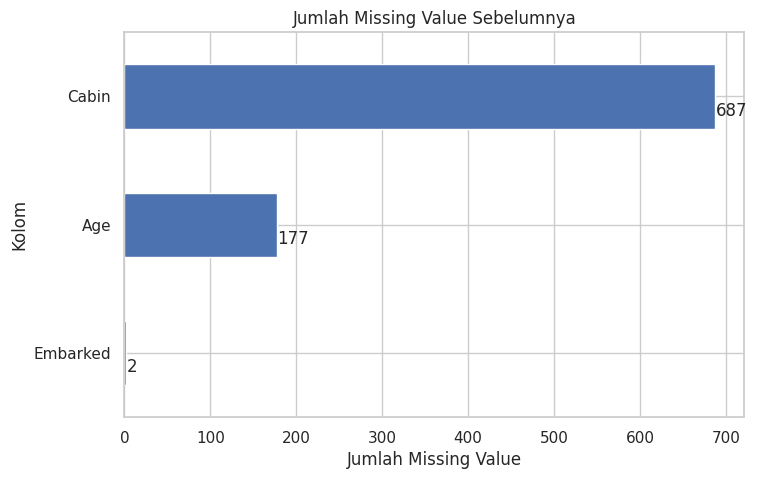

In [45]:
Missing_Real = pd.Series({"Age":177,"Cabin":687, "Embarked":2})

ax = Missing_Real.sort_values().plot(kind="barh")
ax.set_title("Jumlah Missing Value Sebelumnya")
ax.set_ylabel("Kolom")
ax.set_xlabel("Jumlah Missing Value")
for i, v in enumerate(Missing_Real.sort_values()):
    ax.text(v + 1, i - 0.15, str(v))
plt.show()

Interpretasi :  
   
- Nilai hilang terbanyak ada di Cabin, tidak mungkin kita melakukan imputasi karna lebih dari 50% data hilang
-  Untuk Kolom Age Hilang sekitar 177 atau 20% data, kita bisa melalukan imputasi menggunakan Median atau nilai tengahnya yang robust terhadap outlier
- Untuk kolom Embarked hanya 2 data yang hilang, kita bisa melakukan imputasi menggunakan modus atau nilai yang sering muncul dari data Embarked

## b) Tingkat Keselamatan Berdasarkan Jenis Kelamin ( CountPlot )

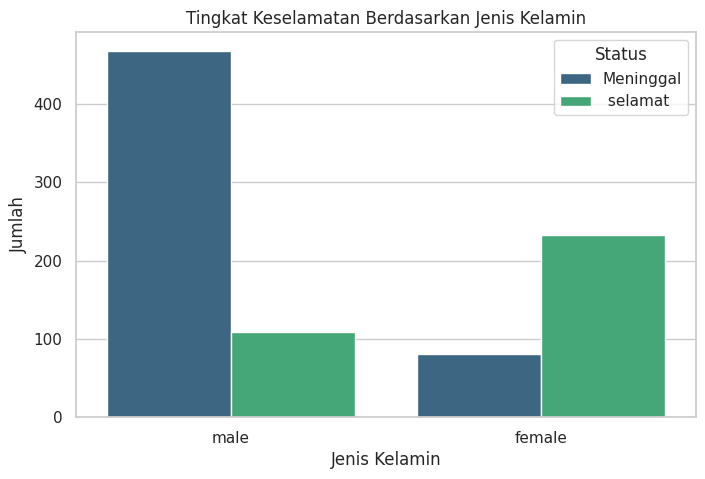

In [46]:
sns.countplot(x="Sex", hue="Status", data=df, palette="viridis")
plt.title("Tingkat Keselamatan Berdasarkan Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Jumlah")
plt.show()


Interpretasi :    
- Berdasarkan Data Penumpang Terbanyak didominasi oleh laki laki, dan Korban yang tidak selamat di Dominasi Oleh laki laki
- Perempuan sebagai minoritas penumpang, tetapi tingkat keselamatanya lebih tinggi daripada laki laki
- Mungkin bisa interpretasi dan dikaitkan dengan Peraturan Darurat : Woman and Childer First

## c) Tingkat Keselamatan Berdasarkan Kelas Tiket Penumpang ( BarPlot )

/tmp/ipykernel_24676/688698805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x="Kelas", y="Survived", palette="viridis")


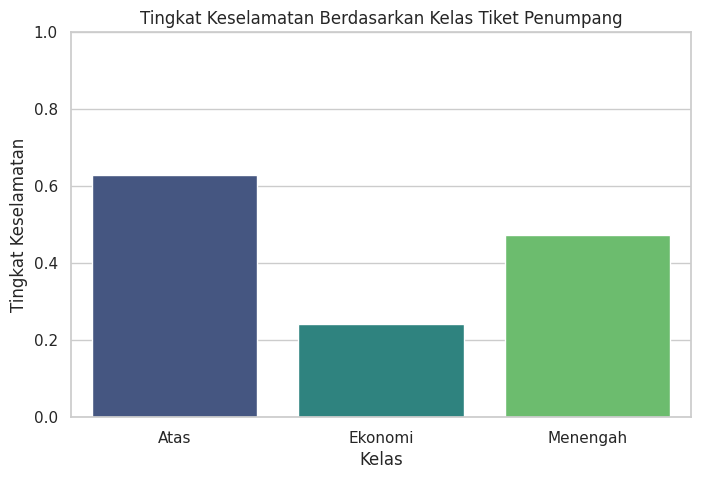

In [47]:
rate = df.groupby("Kelas")["Survived"].mean().reset_index()

sns.barplot(data=rate, x="Kelas", y="Survived", palette="viridis")
plt.title("Tingkat Keselamatan Berdasarkan Kelas Tiket Penumpang")
plt.xlabel("Kelas")
plt.ylabel("Tingkat Keselamatan")
plt.ylim(0, 1)
plt.show()

**Interpretasi:**

- Semakin tinggi kelas tiket, semakin besar peluang selamat.

- Penumpang **Kelas 1** punya peluang selamat jauh lebih tinggi daripada **Kelas 3**

- status sosial-ekonomi ternyata berpengaruh besar terhadap keselamatan.

## d) Distribusi Umur Penumpang ( Histogram )


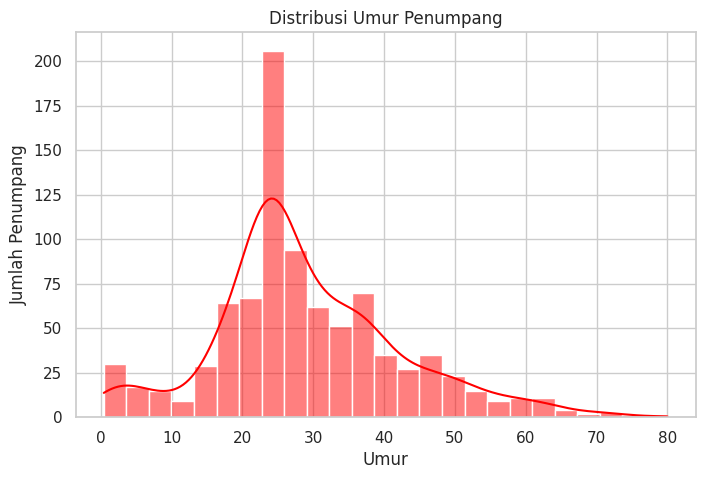

In [48]:
sns.histplot(df["Age"], kde=True, bins=25, color="red")
plt.title("Distribusi Umur Penumpang")
plt.xlabel("Umur")
plt.ylabel("Jumlah Penumpang")
plt.show()

Interpretasi :    
- Distribusi data memiliki puncak tertinggi di umur 24 ,
- ini bisa dipengaruhi oleh imputasi nilai yang kita lakukan sebelumnnya
- ini merupakan tradeoff dari imputasi sederhana yang kita lakukan

In [50]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

/tmp/ipykernel_24676/3493273128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x="FamilySize", y="Survived", palette="viridis")


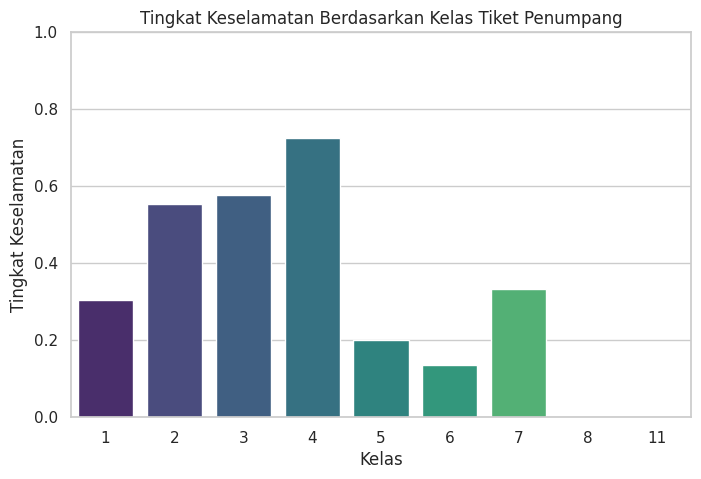

In [52]:
rate = df.groupby("FamilySize")["Survived"].mean().reset_index()

sns.barplot(data=rate, x="FamilySize", y="Survived", palette="viridis")
plt.title("Tingkat Keselamatan Berdasarkan Kelas Tiket Penumpang")
plt.xlabel("Kelas")
plt.ylabel("Tingkat Keselamatan")
plt.ylim(0, 1)
plt.show()

Tingkat Keselamatan Tertinggi terdapat pada jumlah keluarga 2 sampai 4 orang.

- ada indikasi mereka saling bersama dan saling membantu satu sama lain, ketika kecelakaan ini terjadi

/tmp/ipykernel_24676/2066926086.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Kelas', y='Fare', palette="viridis")


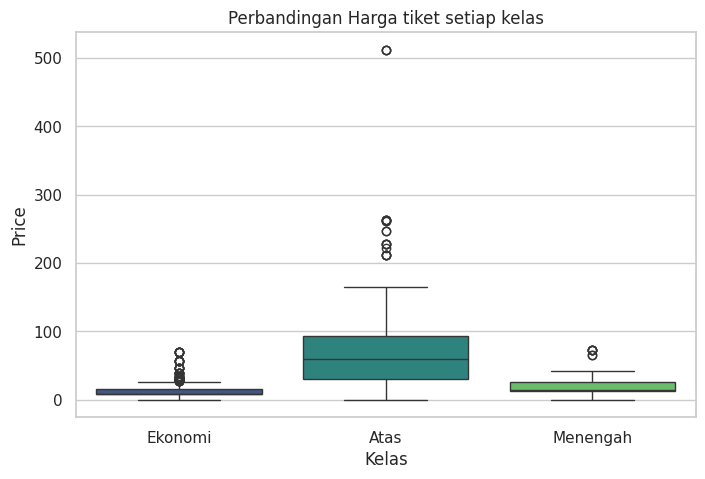

In [55]:
sns.boxplot(data=df, x='Kelas', y='Fare', palette="viridis")
plt.title ("Perbandingan Harga tiket setiap kelas")
plt.xlabel ('Kelas')
plt.ylabel ('Price')
plt.show()

terdapat masing masing outlier dalam setiap kelas, dan ada harga yang sangat tinggi di kelas atas. yang menandakan ini adalah kelas yang super VVIP atau Special Ekslusif

# Kesimpulan dan Insight


Kesimpulan
- Data ini memiliki Missing Values: age(20%), cabin(77%), dan embarked (0.3%)
- Strategi Cleaning Data : Imputasi dengan Median dan Modus, Drop data yang missing value apabila lebih dari 50%

Insight
- Keselamatan sangat dipengaruhi oleh jenis kelamin (Perempuan) dan Jenis Tiket(Kelas atas) mungkin lebih di prioritaskan


## 💼 Rekomendasi & Insight Bisnis

Pola "wanita dan penumpang kelas atas lebih banyak selamat" adalah contoh bagaimana
**faktor sosial-ekonomi** memengaruhi hasil. Untuk analis di bidang asuransi, keselamatan,
atau kebijakan publik, temuan seperti ini mengarahkan **prioritas intervensi** (mis. protokol
evakuasi yang adil) dan menyoroti **kesenjangan** yang perlu ditangani.

### ⚠️ Jebakan Data
- `Cabin` kosong ~77% — **membuang** kolomnya lebih jujur daripada memaksakan imputasi mengada-ada.
- Mengisi `Age` dengan **satu median global** membuat lonjakan tak wajar di sekitar nilai median
  (lihat histogram di atas) dan menutupi perbedaan umur antar kelas. Median **per kelas** lebih
